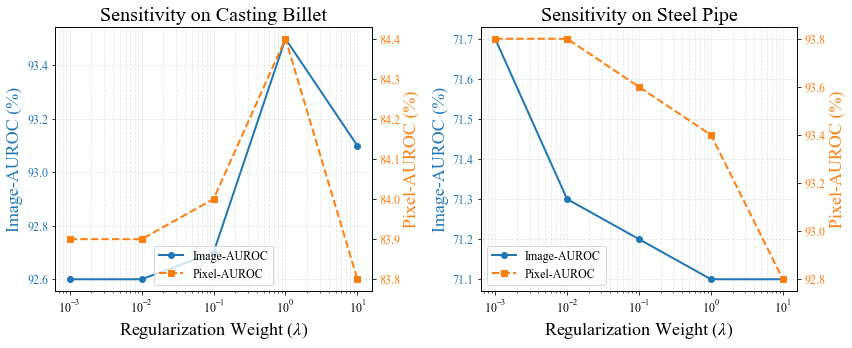

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 核心修改：全局字体设置 (Times New Roman)
# ==========================================
config = {
    "font.family": 'serif',
    "font.serif": ['Times New Roman'],
    "mathtext.fontset": 'stix',  # 设置数学公式字体类似 Times New Roman
    "font.size": 12,             # 全局字号，可根据需要调整
    "axes.unicode_minus": False  # 处理负号显示问题
}
plt.rcParams.update(config)

# --- 数据准备 ---
# Lambda Values (注意：0 不能在对数轴上显示，我们用一个极小值代替或者只画非零部分)
# 这里为了展示趋势，我们从 0.001 开始画
lambdas = [0.001, 0.01, 0.1, 1, 10]
lambda_labels = ['1e-3', '1e-2', '1e-1', '1', '10']

# Casting Billet Data
casting_img = [92.6, 92.6, 92.7, 93.5, 93.1]
casting_pix = [83.9, 83.9, 84.0, 84.4, 83.8]

# Steel Pipe Data
# 注意：lambda=0 和 0.001 的数据是一样的，我们在图注里说明即可
# steel_img = [71.1, 70.7, 70.6, 70.5, 70.5]
# steel_pix = [90.4, 90.4, 90.2, 90.0, 89.4]

steel_img = [71.7, 71.3, 71.2, 71.1, 71.1]
steel_pix = [93.8, 93.8, 93.6, 93.4, 92.8]

# --- 创建画布 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plt.subplots_adjust(wspace=0.3) # 调整子图间距

# ==========================================
# 子图 1: Casting Billet
# ==========================================
color_img = 'tab:blue'
color_pix = 'tab:orange'

# 绘制左轴 (Image-AUROC)
line1, = ax1.plot(lambdas, casting_img, marker='o', color=color_img, label='Image-AUROC', linewidth=2)
ax1.set_xlabel('Regularization Weight ($\lambda$)', fontsize=18)
ax1.set_ylabel('Image-AUROC (%)', color=color_img, fontsize=18)
ax1.tick_params(axis='y', labelcolor=color_img)
ax1.set_xscale('log') # 设置 X 轴为对数坐标
ax1.set_title('Sensitivity on Casting Billet', fontsize=20)
ax1.grid(True, which="both", ls="--", alpha=0.3)

# 绘制右轴 (Pixel-AUROC)
ax1_twin = ax1.twinx()
line2, = ax1_twin.plot(lambdas, casting_pix, marker='s', color=color_pix, label='Pixel-AUROC', linewidth=2, linestyle='--')
ax1_twin.set_ylabel('Pixel-AUROC (%)', color=color_pix, fontsize=18)
ax1_twin.tick_params(axis='y', labelcolor=color_pix)

# 合并图例
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower center')

# ==========================================
# 子图 2: Steel Pipe
# ==========================================
# 绘制左轴 (Image-AUROC)
line3, = ax2.plot(lambdas, steel_img, marker='o', color=color_img, label='Image-AUROC', linewidth=2)
ax2.set_xlabel('Regularization Weight ($\lambda$)', fontsize=18)
ax2.set_ylabel('Image-AUROC (%)', color=color_img, fontsize=18)
ax2.tick_params(axis='y', labelcolor=color_img)
ax2.set_xscale('log')
ax2.set_title('Sensitivity on Steel Pipe', fontsize=20)
ax2.grid(True, which="both", ls="--", alpha=0.3)

# 绘制右轴 (Pixel-AUROC)
ax2_twin = ax2.twinx()
line4, = ax2_twin.plot(lambdas, steel_pix, marker='s', color=color_pix, label='Pixel-AUROC', linewidth=2, linestyle='--')
ax2_twin.set_ylabel('Pixel-AUROC (%)', color=color_pix, fontsize=18)
ax2_twin.tick_params(axis='y', labelcolor=color_pix)

# 合并图例
lines2 = [line3, line4]
labels2 = [l.get_label() for l in lines2]
ax2.legend(lines2, labels2, loc='lower left')

# 保存图片
plt.tight_layout()
plt.savefig('lambda_sensitivity.pdf', dpi=600)
plt.savefig('lambda_sensitivity.jpg', dpi=600)
plt.show()

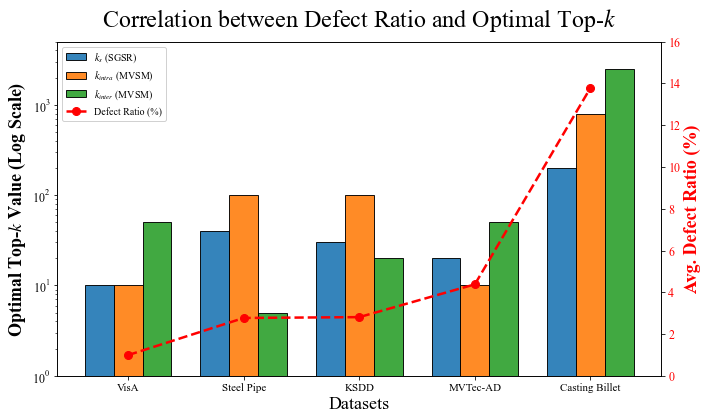

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 核心修改：全局字体设置 (Times New Roman)
# ==========================================
config = {
    "font.family": 'serif',
    "font.serif": ['Times New Roman'],
    "mathtext.fontset": 'stix',  # 设置数学公式字体类似 Times New Roman
    "font.size": 12,             # 全局字号，可根据需要调整
    "axes.unicode_minus": False  # 处理负号显示问题
}
plt.rcParams.update(config)

# === 1. 数据准备 ===
# 按缺陷占比从小到大排序: KSDD(0.5%) -> VisA(1.0%) -> Steel Pipe(2.8%) -> MVTec(4.4%) -> Casting(13.8%)
# 注意：这里取您提供的 KSDD1 (0.5%) 作为代表，或者取平均值。为了展示趋势，排序很重要。

datasets = ['VisA', 'Steel Pipe', 'KSDD', 'MVTec-AD', 'Casting Billet']
defect_ratios = [0.99, 2.77, 2.81, 4.38, 13.79]  # 右轴数据 (%)

# 最优超参数 (左轴数据)
# Order: KSDD, VisA, Steel, MVTec, Casting
k_update = [10, 40, 30, 20, 200]      # SGSR (Refine)
k_intra  = [10, 100, 100, 10, 800]    # MVSM Intra
k_inter  = [50, 5, 20, 50, 2500]      # MVSM Inter

x = np.arange(len(datasets))
width = 0.25  # 柱状图宽度

# === 2. 创建画布 ===
fig, ax1 = plt.subplots(figsize=(10, 6))

# === 3. 绘制左轴 (柱状图 - 超参数) ===
# 使用 Log Scale 因为 2500 和 10 差距太大
ax1.set_yscale('log') 
rects1 = ax1.bar(x - width, k_update, width, label=r'$k_{s}$ (SGSR)', color='#1f77b4', alpha=0.9, edgecolor='black')
rects2 = ax1.bar(x, k_intra, width, label=r'$k_{intra}$ (MVSM)', color='#ff7f0e', alpha=0.9, edgecolor='black')
rects3 = ax1.bar(x + width, k_inter, width, label=r'$k_{inter}$ (MVSM)', color='#2ca02c', alpha=0.9, edgecolor='black')

ax1.set_ylabel('Optimal Top-$k$ Value (Log Scale)', fontsize=18, fontweight='bold')
ax1.set_xlabel('Datasets', fontsize=18)
ax1.set_xticks(x)
ax1.set_xticklabels(datasets, fontsize=11)
ax1.tick_params(axis='y', which='minor') # 显示 Log 刻度
ax1.set_ylim(1, 5000) # 设置范围，保证图例不遮挡

# === 4. 绘制右轴 (折线图 - 缺陷占比) ===
ax2 = ax1.twinx()
ax2.plot(x, defect_ratios, color='red', marker='o', linewidth=2.5, linestyle='--', markersize=8, label='Defect Ratio (%)')
ax2.set_ylabel('Avg. Defect Ratio (%)', color='red', fontsize=18, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 16) # 稍微留点空间

# === 5. 图例与美化 ===
# 合并两个轴的图例
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=10, framealpha=0.9)

plt.title('Correlation between Defect Ratio and Optimal Top-$k$', fontsize=24, pad=15)
plt.tight_layout()

# 保存
plt.savefig('hyperparameter_correlation.pdf', dpi=600)
plt.savefig('hyperparameter_correlation.jpg', dpi=600) # 方便预览
plt.show()

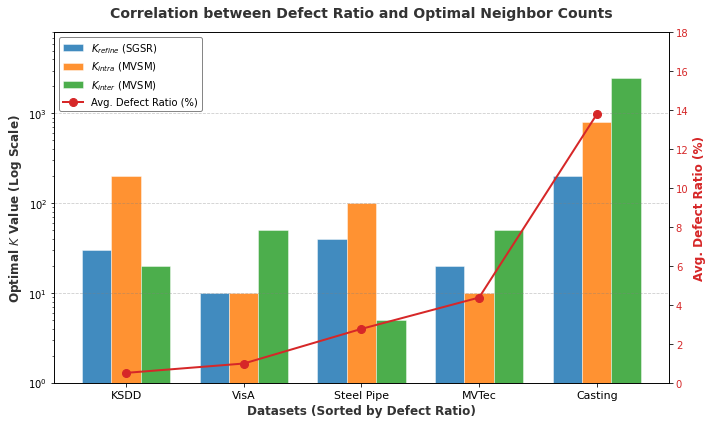

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# === 1. 数据准备 ===
# 按缺陷占比从小到大排序
datasets = ['KSDD', 'VisA', 'Steel Pipe', 'MVTec', 'Casting']
defect_ratios = [0.51, 0.99, 2.77, 4.38, 13.79]  # 右轴数据 (%)

# 最优超参数 (左轴数据)
k_update = [30, 10, 40, 20, 200]      # SGSR (Refine)
k_intra  = [200, 10, 100, 10, 800]    # MVSM Intra
k_inter  = [20, 50, 5, 50, 2500]      # MVSM Inter

x = np.arange(len(datasets))
width = 0.25  # 柱状图宽度

# === 2. 配色方案 (匹配 image_f1387c.png 风格) ===
# 使用 Matplotlib 标准 tab10 色盘，保证与您其他图表风格一致
color_bar1 = '#1f77b4'  # tab:blue (经典蓝)
color_bar2 = '#ff7f0e'  # tab:orange (经典橙)
color_bar3 = '#2ca02c'  # tab:green (经典绿)
color_line = '#d62728'  # tab:red (经典红) - 用于右轴折线，突出显示

# === 3. 创建画布 ===
fig, ax1 = plt.subplots(figsize=(10, 6))

# === 4. 绘制左轴 (柱状图 - 超参数) ===
ax1.set_yscale('log')  # 对数坐标
# 添加略微的透明度 alpha=0.85，让颜色不那么刺眼，更有质感
rects1 = ax1.bar(x - width, k_update, width, label=r'$K_{refine}$ (SGSR)', color=color_bar1, alpha=0.85, edgecolor='white', linewidth=0.5)
rects2 = ax1.bar(x, k_intra, width, label=r'$K_{intra}$ (MVSM)', color=color_bar2, alpha=0.85, edgecolor='white', linewidth=0.5)
rects3 = ax1.bar(x + width, k_inter, width, label=r'$K_{inter}$ (MVSM)', color=color_bar3, alpha=0.85, edgecolor='white', linewidth=0.5)

ax1.set_ylabel('Optimal $K$ Value (Log Scale)', fontsize=12, fontweight='bold', color='#333333')
ax1.set_xlabel('Datasets (Sorted by Defect Ratio)', fontsize=12, fontweight='bold', color='#333333')
ax1.set_xticks(x)
ax1.set_xticklabels(datasets, fontsize=11)
ax1.tick_params(axis='y', which='major', labelsize=10)
ax1.set_ylim(1, 8000) # 稍微调高上限，给图例留空间

# 设置网格 (匹配参考图的虚线风格)
ax1.grid(True, which='major', axis='y', linestyle='--', alpha=0.4, color='gray')

# === 5. 绘制右轴 (折线图 - 缺陷占比) ===
ax2 = ax1.twinx()
# 使用红色折线，带实心圆点，linewidth=2 匹配参考图的线条粗细
ax2.plot(x, defect_ratios, color=color_line, marker='o', linewidth=2, markersize=8, label='Avg. Defect Ratio (%)', linestyle='-')

ax2.set_ylabel('Avg. Defect Ratio (%)', color=color_line, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_line, labelsize=10)
ax2.set_ylim(0, 18) # 留出空间

# === 6. 图例与美化 ===
# 合并图例，并设置背景半透明
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=10, framealpha=0.95, edgecolor='gray')

plt.title('Correlation between Defect Ratio and Optimal Neighbor Counts', fontsize=14, pad=15, fontweight='bold', color='#333333')
plt.tight_layout()

# 保存
plt.savefig('hyperparameter_correlation_matched.pdf', dpi=300)
plt.savefig('hyperparameter_correlation_matched.png', dpi=300) # 方便预览
plt.show()

Scanning /Volumes/cn1T/4090/datasets/MVTec_AD...
  Found 6612 images. Selecting one randomly.
  -> Selected category/folder: grid
Scanning /Volumes/cn1T/4090/datasets/own_anomaly_detect/Visa...
  Found 12021 images. Selecting one randomly.
  -> Selected category/folder: macaroni1
Scanning /Volumes/cn1T/4090/datasets/own_anomaly_detect/KolektorSDD2...
  Found 3691 images. Selecting one randomly.
  -> Selected category/folder: ground_truth
Scanning /Volumes/cn1T/4090/datasets/own_anomaly_detect/steel_pipe...
  Found 1776 images. Selecting one randomly.
  -> Selected category/folder: ground_truth
Scanning /Volumes/cn1T/4090/datasets/own_anomaly_detect/casting_billet...
  Found 1840 images. Selecting one randomly.
  -> Selected category/folder: test
Saving teaser to dataset_teaser_random_category.pdf...


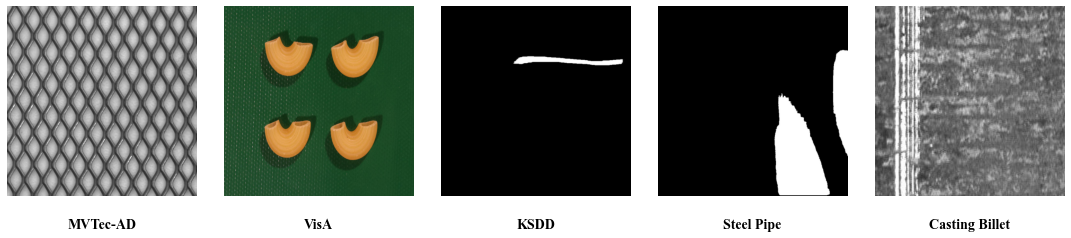

In [30]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# ================= 配置区域 (关键修改) =================
# 对于 MVTec 和 VisA，请指向包含所有物体子文件夹的【根目录】。
# 对于其他数据集，指向包含图片的任意文件夹即可（脚本会递归查找）。
root = '/Volumes/cn1T/4090/datasets/'
DATASET_ROOTS = {
    # MVTec AD: 指向根目录，例如包含 bottle, cable, capsule... 的文件夹
    'MVTec-AD': root+'MVTec_AD', 
    
    # VisA: 指向根目录，例如包含 pcb1, candle, macroni... 的文件夹
    'VisA': root+'own_anomaly_detect/Visa',
    
    # KSDD, Steel Pipe, Casting: 如果没有子类，指向包含图片的目录即可(例如 test 或 train)
    # 脚本会查找该目录及其所有子目录下的图片
    'KSDD': root+'own_anomaly_detect/KolektorSDD2',
    'Steel Pipe': root+'own_anomaly_detect/steel_pipe',
    'Casting Billet': root+'own_anomaly_detect/casting_billet'
}

OUTPUT_PATH = 'dataset_teaser_random_category.pdf'
IMAGE_SIZE = (512, 512) # 统一显示大小
# =====================================================

def get_random_image_recursive(root_folder):
    """
    递归遍历 root_folder 及其所有子文件夹，
    收集所有图片路径，然后随机返回一个。
    """
    valid_exts = ['.jpg', '.png', '.bmp', '.tif', '.jpeg']
    all_images = []
    
    print(f"Scanning {root_folder}...")
    # os.walk 会遍历目录树
    for dirpath, dirnames, filenames in os.walk(root_folder):
        for f in filenames:
            if os.path.splitext(f)[1].lower() in valid_exts:
                full_path = os.path.join(dirpath, f)
                all_images.append(full_path)
                
    if not all_images:
        print(f"  Warning: No images found in {root_folder} or its subdirectories.")
        return None
    
    print(f"  Found {len(all_images)} images. Selecting one randomly.")
    selected_img = random.choice(all_images)
    
    # (可选) 打印一下选中了哪个子类，方便确认
    # 尝试从路径中提取类别名，这依赖于文件夹结构，仅供参考
    try:
        # 假设路径结构是 dataset_root/category/...
        rel_path = os.path.relpath(selected_img, root_folder)
        category = rel_path.split(os.sep)[0]
        print(f"  -> Selected category/folder: {category}")
    except:
        pass
        
    return selected_img

def generate_teaser():
    # 创建 1行 5列 的画布
    fig, axes = plt.subplots(1, 5, figsize=(15, 3.2), constrained_layout=True)
    
    # 设置字体
    plt.rcParams.update({'font.family': 'serif', 'font.size': 12})

    names = list(DATASET_ROOTS.keys())
    
    for i, ax in enumerate(axes):
        name = names[i]
        root_path = DATASET_ROOTS[name]
        
        # 使用新的递归查找函数
        img_path = get_random_image_recursive(root_path)
        
        if img_path:
            try:
                img = Image.open(img_path).convert('RGB')
                # 使用高质量重采样调整大小
                # 兼容旧版 Pillow 的写法
                try:
                    resample_filter = Image.Resampling.LANCZOS
                except AttributeError:
                    resample_filter = Image.LANCZOS  # 旧版写法

                img = img.resize(IMAGE_SIZE, resample_filter)
                ax.imshow(img)
            except Exception as e:
                 print(f"Error loading {img_path}: {e}")
                 ax.imshow(np.zeros((IMAGE_SIZE[1], IMAGE_SIZE[0], 3)))
        else:
            # 如果路径不对，显示全黑
            ax.imshow(np.zeros((IMAGE_SIZE[1], IMAGE_SIZE[0], 3)))
            ax.text(IMAGE_SIZE[0]//2, IMAGE_SIZE[1]//2, "Path Error", color='white', ha='center')

        # 去掉坐标轴
        ax.axis('off')
        
        # 在图片下方添加数据集名称作为 Label
        # y值调整标题在图片下方的位置
        ax.set_title(name, y=-0.2, fontsize=14, fontweight='bold')

    print(f"Saving teaser to {OUTPUT_PATH}...")
    plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
    # plt.show() # 如果不需要弹出窗口可以注释掉

if __name__ == "__main__":
    generate_teaser()

In [31]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# ================= 配置区域 =================
# 请将路径指向各数据集的 test 根目录
# 代码会自动递归搜索该目录下的所有子文件夹
DATASET_CONFIG = {
    'MVTec AD': '/Volumes/cn1T/4090/datasets/MVTec_AD', # 指向包含 bottle, cable... 的根目录
    'VisA':     '/Volumes/cn1T/4090/datasets/own_anomaly_detect/Visa',
    'KSDD':     '/Volumes/cn1T/4090/datasets/own_anomaly_detect/KolektorSDD2/test',
    'Steel Pipe': '/Volumes/cn1T/4090/datasets/own_anomaly_detect/steel_pipe/test',
    'Casting Billet': '/Volumes/cn1T/4090/datasets/own_anomaly_detect/casting_billet/test'
}

# 输出设置
OUTPUT_DIR = 'dataset_grids'
IMG_SIZE = (256, 256) # 统一缩放大小
# ===========================================

def get_all_test_images(root_path):
    """递归获取指定路径下的所有图片"""
    valid_exts = ['.jpg', '.png', '.bmp', '.tif', '.jpeg']
    all_imgs = []
    
    # 针对 MVTec 和 VisA 这种有子类的，需要特殊处理一下路径逻辑
    # 如果路径下直接就有图片(如KSDD)，直接扫；如果全是文件夹(如MVTec)，扫子文件夹的test
    
    for dirpath, dirnames, filenames in os.walk(root_path):
        # 简单的过滤：我们只关心路径里包含 'test' 或者 'Anomaly' (针对VisA) 的图
        # 或者您可以简单点，只配置到具体的 test 目录
        for f in filenames:
            if os.path.splitext(f)[1].lower() in valid_exts:
                all_imgs.append(os.path.join(dirpath, f))
    return all_imgs

def generate_compact_grid(dataset_name, root_path):
    print(f"Processing {dataset_name}...")
    
    # 1. 获取所有图片
    images = get_all_test_images(root_path)
    
    # 针对 MVTec/VisA 这种根目录结构，可能需要更严格的过滤，
    # 这里假设您配置的路径下全是您想要展示的测试图
    
    if len(images) < 25:
        print(f"  Warning: Only found {len(images)} images in {root_path}. Duplicating to fill 25.")
        if len(images) == 0: return
        selected_imgs = images * (25 // len(images) + 1)
        selected_imgs = selected_imgs[:25]
    else:
        selected_imgs = random.sample(images, 25)
        
    # 2. 创建画布 5x5
    fig, axes = plt.subplots(5, 5, figsize=(10, 10))
    # 调整间距为 0，实现紧凑效果
    plt.subplots_adjust(wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)
    
    for i, ax in enumerate(axes.flat):
        img_path = selected_imgs[i]
        try:
            img = Image.open(img_path).convert('RGB')
            # 兼容旧版 Pillow
            if hasattr(Image, 'Resampling'):
                resample = Image.Resampling.LANCZOS
            else:
                resample = Image.LANCZOS
            img = img.resize(IMG_SIZE, resample)
            ax.imshow(img)
        except Exception as e:
            print(f"  Error: {e}")
            ax.imshow(np.zeros((IMG_SIZE[1], IMG_SIZE[0], 3)))
            
        ax.axis('off') # 关掉坐标轴
        
    # 3. 保存
    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)
        
    safe_name = dataset_name.replace(' ', '_').lower()
    save_path = os.path.join(OUTPUT_DIR, f'grid_{safe_name}.pdf')
    
    plt.savefig(save_path, dpi=200, bbox_inches='tight', pad_inches=0)
    plt.close()
    print(f"  Saved to {save_path}")

if __name__ == "__main__":
    for name, path in DATASET_CONFIG.items():
        generate_compact_grid(name, path)

Processing MVTec AD...
  Saved to dataset_grids/grid_mvtec_ad.pdf
Processing VisA...
  Saved to dataset_grids/grid_visa.pdf
Processing KSDD...
  Saved to dataset_grids/grid_ksdd.pdf
Processing Steel Pipe...
  Saved to dataset_grids/grid_steel_pipe.pdf
Processing Casting Billet...
  Saved to dataset_grids/grid_casting_billet.pdf


In [ ]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

def verify_misplaced_mask(dataset_root, category='transistor', defect_type='misplaced'):
    """
    随机抽取一张指定缺陷的图片，打印绝对路径并进行可视化对比。
    """
    # 构建路径
    img_dir = os.path.join(dataset_root, category, 'test', defect_type)
    gt_dir = os.path.join(dataset_root, category, 'ground_truth', defect_type)
    
    if not os.path.exists(img_dir) or not os.path.exists(gt_dir):
        print(f"路径不存在，请检查数据集根目录: {dataset_root}")
        return

    # 获取所有图片并随机选一张
    img_files = [f for f in os.listdir(img_dir) if f.endswith('.png')]
    if not img_files:
        print("未找到图片文件。")
        return
        
    target_file = random.choice(img_files)
    mask_file = target_file.replace('.png', '_mask.png')
    
    # 获取绝对路径
    img_path_abs = os.path.abspath(os.path.join(img_dir, target_file))
    mask_path_abs = os.path.abspath(os.path.join(gt_dir, mask_file))
    
    # 1. 打印输出路径
    print("="*50)
    print(f"正在验证缺陷类型: {category} -> {defect_type}")
    print(f"抽取文件: {target_file}")
    print(f"原图绝对路径:\n{img_path_abs}")
    print(f"官方Mask绝对路径:\n{mask_path_abs}")
    print("="*50)
    
    # 2. 读取图像
    img = cv2.cvtColor(cv2.imread(img_path_abs), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path_abs, cv2.IMREAD_GRAYSCALE)
    
    # 创建红色半透明叠加层
    overlay = img.copy()
    overlay[mask > 0] = overlay[mask > 0] * 0.5 + np.array([255, 0, 0]) * 0.5
    
    # 3. 绘图展示
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title(f"Original Image\n{target_file}")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title(f"Official GT Mask\n{mask_file}")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# 运行代码，替换为你的 MVTec 数据集绝对路径
# verify_misplaced_mask('/你的/mvtec/路径')

In [32]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# ================= 配置区域 =================
DATASET_CONFIG = {
    'MVTec AD': '/Volumes/cn1T/4090/datasets/MVTec_AD', # 指向包含 bottle, cable... 的根目录
    'VisA':     '/Volumes/cn1T/4090/datasets/own_anomaly_detect/Visa',
    'KSDD':     '/Volumes/cn1T/4090/datasets/own_anomaly_detect/KolektorSDD2/test',
    'Steel Pipe': '/Volumes/cn1T/4090/datasets/own_anomaly_detect/steel_pipe/test',
    'Casting Billet': '/Volumes/cn1T/4090/datasets/own_anomaly_detect/casting_billet/test'
}

OUTPUT_DIR = 'dataset_grids'
IMG_SIZE = (256, 256) 
# ===========================================

def is_valid_image(file_path):
    """
    核心过滤函数：判断图片是否是有效的 RGB 原图
    """
    path_lower = file_path.lower()
    valid_exts = ['.jpg', '.png', '.bmp', '.tif', '.jpeg']
    
    # 1. 检查扩展名
    if not any(path_lower.endswith(ext) for ext in valid_exts):
        return False
        
    # 2. 【关键】剔除包含掩码关键词的路径
    # MVTec 通常在 'ground_truth' 文件夹里
    # VisA 通常在 'Masks' 文件夹里
    # 一般掩码文件名可能包含 'mask', 'label', 'gt'
    forbidden_keywords = [
        'mask', 'ground_truth', 'gt', 'label', 'annot', # 常见掩码目录/文件名
        'seg', 'segmentation'
    ]
    
    # 如果路径中包含任何一个禁止词，就丢弃
    # 注意：这里用 path_lower 检查整个路径
    for k in forbidden_keywords:
        # 特殊处理：有些文件名叫 "mask.png" 或者目录叫 "ground_truth"
        # 加上分隔符判断更准确，或者直接判断字符串包含
        if k in path_lower:
            return False
            
    # 3. (可选) 对于 MVTec/VisA，强制要求路径包含 'test' 或 'anomaly'
    # 这样可以避免把 train 里的 good 图混进来（如果你只想展示缺陷图）
    # if 'test' not in path_lower and 'anomaly' not in path_lower:
    #    return False

    return True

def get_clean_test_images(root_path):
    """递归获取清洗后的图片路径"""
    clean_images = []
    
    print(f"Scanning {root_path}...")
    for dirpath, dirnames, filenames in os.walk(root_path):
        for f in filenames:
            full_path = os.path.join(dirpath, f)
            
            # 使用过滤函数
            if is_valid_image(full_path):
                clean_images.append(full_path)
                
    return clean_images

def generate_compact_grid(dataset_name, root_path):
    print(f"Processing {dataset_name}...")
    
    # 获取图片
    images = get_clean_test_images(root_path)
    
    print(f"  Found {len(images)} valid images (masks filtered).")
    
    if len(images) < 25:
        print(f"  Warning: Not enough images. Found {len(images)}, duplicating to fill 25.")
        if len(images) == 0: return
        selected_imgs = images * (25 // len(images) + 1)
        selected_imgs = selected_imgs[:25]
    else:
        selected_imgs = random.sample(images, 25)
        
    # 创建 5x5 画布
    fig, axes = plt.subplots(5, 5, figsize=(10, 10))
    plt.subplots_adjust(wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)
    
    for i, ax in enumerate(axes.flat):
        img_path = selected_imgs[i]
        try:
            img = Image.open(img_path).convert('RGB')
            # 兼容性写法
            if hasattr(Image, 'Resampling'):
                resample = Image.Resampling.LANCZOS
            else:
                resample = Image.LANCZOS
            img = img.resize(IMG_SIZE, resample)
            ax.imshow(img)
        except Exception as e:
            print(f"  Error loading {img_path}: {e}")
            ax.imshow(np.zeros((IMG_SIZE[1], IMG_SIZE[0], 3)))
            
        ax.axis('off')
        
    # 保存
    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)
        
    safe_name = dataset_name.replace(' ', '_').lower()
    save_path = os.path.join(OUTPUT_DIR, f'grid_{safe_name}.pdf')
    
    plt.savefig(save_path, dpi=200, bbox_inches='tight', pad_inches=0)
    plt.close()
    print(f"  Saved to {save_path}")

if __name__ == "__main__":
    for name, path in DATASET_CONFIG.items():
        generate_compact_grid(name, path)

Processing MVTec AD...
Scanning /Volumes/cn1T/4090/datasets/MVTec_AD...
  Found 5354 valid images (masks filtered).
  Saved to dataset_grids/grid_mvtec_ad.pdf
Processing VisA...
Scanning /Volumes/cn1T/4090/datasets/own_anomaly_detect/Visa...
  Found 10821 valid images (masks filtered).
  Saved to dataset_grids/grid_visa.pdf
Processing KSDD...
Scanning /Volumes/cn1T/4090/datasets/own_anomaly_detect/KolektorSDD2/test...
  Found 1250 valid images (masks filtered).
  Saved to dataset_grids/grid_ksdd.pdf
Processing Steel Pipe...
Scanning /Volumes/cn1T/4090/datasets/own_anomaly_detect/steel_pipe/test...
  Found 929 valid images (masks filtered).
  Saved to dataset_grids/grid_steel_pipe.pdf
Processing Casting Billet...
Scanning /Volumes/cn1T/4090/datasets/own_anomaly_detect/casting_billet/test...
  Found 860 valid images (masks filtered).
  Saved to dataset_grids/grid_casting_billet.pdf


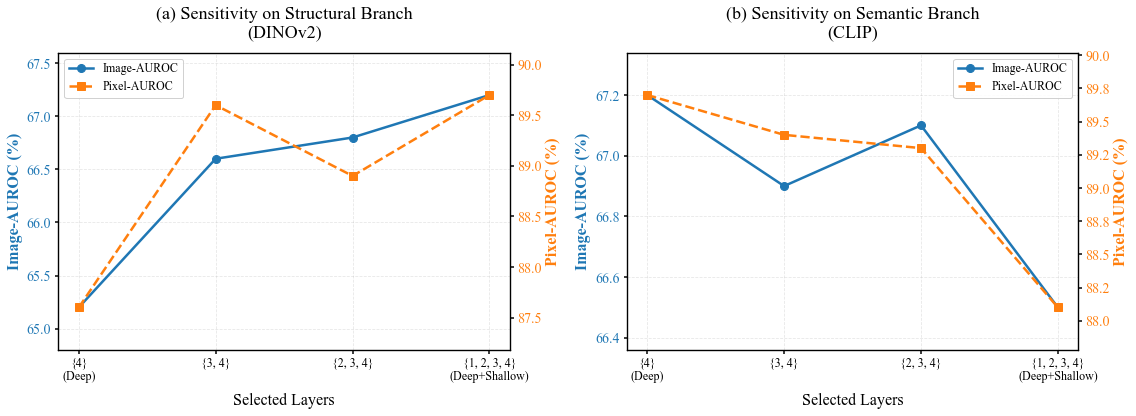

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

# ================= 1. 数据准备 =================
# X轴标签：层数累加
labels = ['{4}\n(Deep)', '{3, 4}', '{2, 3, 4}', '{1, 2, 3, 4}\n(Deep+Shallow)']
x = np.arange(len(labels))

# --- DINOv2 数据 (Structural Branch) ---
dino_image = [65.2, 66.6, 66.8, 67.2]  # 左轴 (蓝色实线)
dino_pixel = [87.6, 89.6, 88.9, 89.7]  # 右轴 (橙色虚线)

# --- CLIP 数据 (Semantic Branch) ---
clip_image = [67.2, 66.9, 67.1, 66.5]  # 左轴
clip_pixel = [89.7, 89.4, 89.3, 88.1]  # 右轴

# ================= 2. 样式设置 =================
# 设置全局字体为 Times New Roman (学术标准)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 14
plt.rcParams['axes.linewidth'] = 1.2  # 边框变粗

# 颜色定义 (仿照您上传的图片)
color_img = '#1f77b4'  # 经典蓝
color_pix = '#ff7f0e'  # 经典橙

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
# 调整子图间距，防止Y轴标签重叠
plt.subplots_adjust(wspace=0.3)

# ================= 3. 绘图函数封装 =================
def plot_dual_axis(ax_left, x_data, y_left, y_right, title, xlabel):
    # --- 左轴绘制 (Image AUC) ---
    ln1 = ax_left.plot(x_data, y_left, color=color_img, marker='o', linestyle='-', 
                       linewidth=2.5, markersize=8, label='Image-AUROC')
    
    ax_left.set_xlabel(xlabel, fontsize=16, labelpad=10)
    ax_left.set_ylabel('Image-AUROC (%)', color=color_img, fontsize=16, fontweight='bold')
    ax_left.tick_params(axis='y', labelcolor=color_img, width=1.5)
    ax_left.tick_params(axis='x', width=1.5)
    
    # 设置左轴范围 (自动扩展一点边距)
    pad_l = (max(y_left) - min(y_left)) * 0.2
    ax_left.set_ylim(min(y_left) - pad_l, max(y_left) + pad_l)
    ax_left.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    # --- 右轴绘制 (Pixel AUC) ---
    ax_right = ax_left.twinx()  # 关键：创建共享X轴的双胞胎轴
    ln2 = ax_right.plot(x_data, y_right, color=color_pix, marker='s', linestyle='--', 
                        linewidth=2.5, markersize=8, label='Pixel-AUROC')
    
    ax_right.set_ylabel('Pixel-AUROC (%)', color=color_pix, fontsize=16, fontweight='bold')
    ax_right.tick_params(axis='y', labelcolor=color_pix, width=1.5)
    
    # 设置右轴范围
    pad_r = (max(y_right) - min(y_right)) * 0.2
    ax_right.set_ylim(min(y_right) - pad_r, max(y_right) + pad_r)
    ax_right.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

    # --- 标题与网格 ---
    ax_left.set_title(title, fontsize=18, pad=15)
    ax_left.grid(True, linestyle='--', alpha=0.3)  # 网格基于左轴
    ax_left.set_xticks(x_data)
    ax_left.set_xticklabels(labels, fontsize=12)

    # --- 合并图例 ---
    # 因为有两个轴，需要把图例句柄合并在一起显示
    lns = ln1 + ln2
    labs = [l.get_label() for l in lns]
    ax_left.legend(lns, labs, loc='best', fontsize=12, frameon=True, fancybox=True, framealpha=0.9)

# ================= 4. 执行绘图 =================

# 绘制图 (a) DINOv2
plot_dual_axis(ax1, x, dino_image, dino_pixel, 
               title='(a) Sensitivity on Structural Branch\n(DINOv2)', 
               xlabel='Selected Layers')

# 绘制图 (b) CLIP
plot_dual_axis(ax2, x, clip_image, clip_pixel, 
               title='(b) Sensitivity on Semantic Branch\n(CLIP)', 
               xlabel='Selected Layers')

# 保存
plt.tight_layout()
plt.savefig('ablation_dual_axis.pdf', bbox_inches='tight')
plt.savefig('ablation_dual_axis.png', dpi=300, bbox_inches='tight')
plt.show()

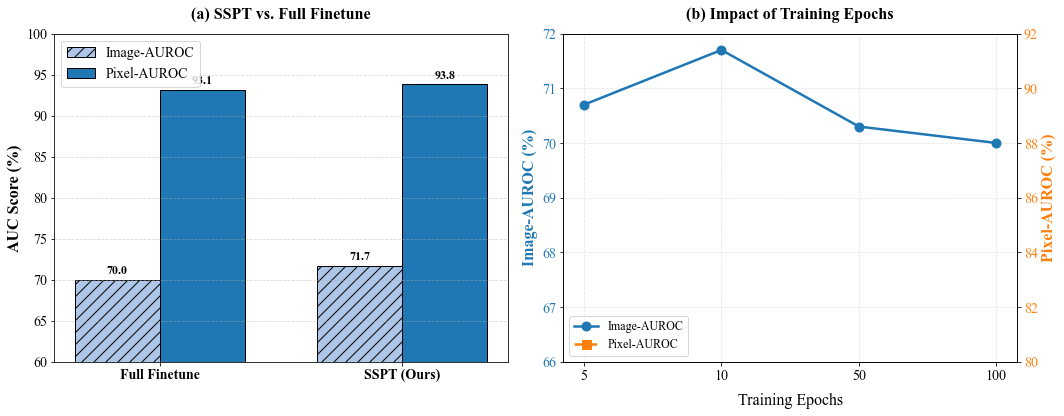

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter

# ================= 数据准备 =================

# --- 实验 1: SSPT vs Full Finetune (Steel Pipe) ---
methods = ['Full Finetune', 'SSPT (Ours)']
# Image AUC
img_scores = [70, 71.7]
# Pixel AUC
pix_scores = [93.1, 93.8]

# --- 实验 2: Epoch Sensitivity ---
epochs = ['5', '10', '50', '100']  # Treat as categories for even spacing
epoch_img = [70.7, 71.7, 70.3, 70]
epoch_pix = [93.2, 93.8, 93.8, 93.7]

# ================= 绘图设置 =================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 14

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plt.subplots_adjust(wspace=0.3)

# 颜色定义
color_blue = '#1f77b4'  # SSPT / Image
color_orange = '#ff7f0e' # Finetune / Pixel
color_gray = '#7f7f7f'   # 对比色

# ================= 子图 1: SSPT vs Finetune (Bar Chart) =================
x = np.arange(len(methods))
width = 0.35

# 绘制柱子
rects1 = ax1.bar(x - width/2, img_scores, width, label='Image-AUROC', color='#aec7e8', edgecolor='black', hatch='//') # 浅蓝
rects2 = ax1.bar(x + width/2, pix_scores, width, label='Pixel-AUROC', color=color_blue, edgecolor='black') # 深蓝

ax1.set_ylabel('AUC Score (%)', fontsize=16, fontweight='bold')
ax1.set_title('(a) SSPT vs. Full Finetune', fontsize=16, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(methods, fontsize=14, fontweight='bold')
ax1.set_ylim(60, 100) # 设置范围让差距更明显
ax1.legend(loc='upper left', frameon=True)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# 自动标注数值
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax1.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

autolabel(rects1)
autolabel(rects2)


# ================= 子图 2: Epoch Sensitivity (Dual Axis Line) =================
x_epochs = np.arange(len(epochs))  # [0, 1, 2, 3]

# 左轴: Image AUC
ln1 = ax2.plot(x_epochs, epoch_img, color=color_blue, marker='o', linestyle='-', 
               linewidth=2.5, markersize=9, label='Image-AUROC')
ax2.set_xlabel('Training Epochs', fontsize=16, labelpad=10)
ax2.set_ylabel('Image-AUROC (%)', color=color_blue, fontsize=16, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_blue)
ax2.set_ylim(66, 72)  # 局部放大 Image 变化

# 右轴: Pixel AUC
ax2_right = ax2.twinx()
ln2 = ax2_right.plot(x_epochs, epoch_pix, color=color_orange, marker='s', linestyle='--', 
                     linewidth=2.5, markersize=9, label='Pixel-AUROC')
ax2_right.set_ylabel('Pixel-AUROC (%)', color=color_orange, fontsize=16, fontweight='bold')
ax2_right.tick_params(axis='y', labelcolor=color_orange)
ax2_right.set_ylim(80, 92) # 局部放大 Pixel 变化

# 标题与刻度
ax2.set_title('(b) Impact of Training Epochs', fontsize=16, fontweight='bold', pad=15)
ax2.set_xticks(x_epochs)
ax2.set_xticklabels(epochs, fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.3)

# 合并图例
lns = ln1 + ln2
labs = [l.get_label() for l in lns]
ax2.legend(lns, labs, loc='lower left', fontsize=12)

# 保存
plt.tight_layout()
plt.savefig('ablation_finetune_epoch.pdf', bbox_inches='tight')
plt.savefig('ablation_finetune_epoch.png', dpi=300, bbox_inches='tight')
plt.show()

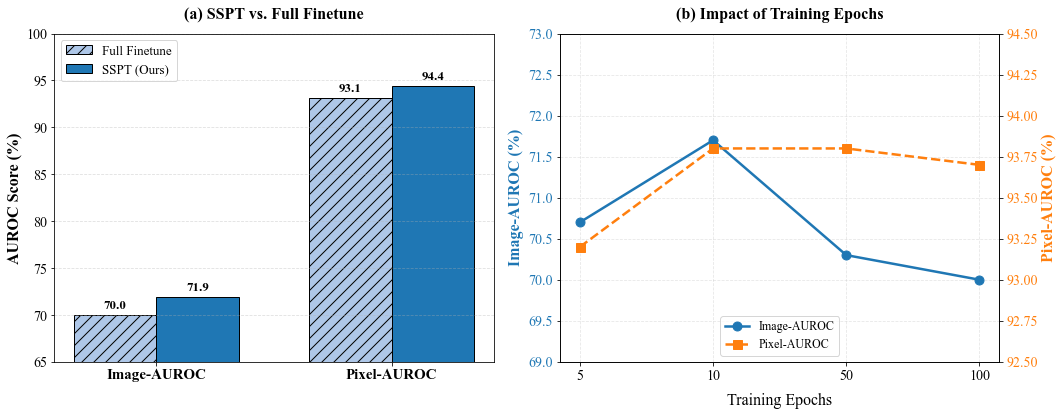

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# ================= 数据准备 =================

# --- 实验 1: 指标对比 (以指标为横坐标) ---
metrics = ['Image-AUROC', 'Pixel-AUROC']
finetune_scores = [70.0, 93.1]
sspt_scores = [71.9, 94.4]

# --- 实验 2: Epoch Sensitivity ---
epochs = ['5', '10', '50', '100']  
epoch_img = [70.7, 71.7, 70.3, 70.0]
epoch_pix = [93.2, 93.8, 93.8, 93.7]

# ================= 绘图设置 =================
plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = ['Times New Roman'] # 确保本地有此字体
plt.rcParams['font.size'] = 14

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plt.subplots_adjust(wspace=0.3) 

# 学术顶会经典配色
color_baseline = '#8da0cb' # 灰蓝色 (Full Finetune)
color_ours = '#fc8d62'     # 砖红色/珊瑚橘 (SSPT) - 突出显示你的方法

color_line_img = '#1f77b4' # 经典蓝 (折线图 Image)
color_line_pix = '#ff7f0e' # 经典橙 (折线图 Pixel)

# ================= 子图 1: SSPT vs Finetune (以指标为 X 轴) =================
x = np.arange(len(metrics))
width = 0.35

# 绘制柱子 (同一个 Y 轴)
rects1 = ax1.bar(x - width/2, finetune_scores, width, label='Full Finetune', color='#aec7e8', edgecolor='black', hatch='//') 
rects2 = ax1.bar(x + width/2, sspt_scores, width, label='SSPT (Ours)', color=color_blue, edgecolor='black')

ax1.set_ylabel('AUROC Score (%)', fontsize=16, fontweight='bold')
ax1.set_title('(a) SSPT vs. Full Finetune', fontsize=16, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=15, fontweight='bold')
ax1.set_ylim(65, 100) # 统一设置一个涵盖所有数据的量程
ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.legend(loc='upper left', frameon=True, fontsize=13)

# 自动标注数值
def autolabel(ax, rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=13, fontweight='bold')

autolabel(ax1, rects1)
autolabel(ax1, rects2)

# ================= 子图 2: Epoch Sensitivity (双 Y 轴折线图) =================
x_epochs = np.arange(len(epochs))  

# 左轴: Image AUC
ln1 = ax2.plot(x_epochs, epoch_img, color=color_line_img, marker='o', linestyle='-', 
               linewidth=2.5, markersize=9, label='Image-AUROC')
ax2.set_xlabel('Training Epochs', fontsize=16, labelpad=10)
ax2.set_ylabel('Image-AUROC (%)', color=color_line_img, fontsize=16, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_line_img)
ax2.set_ylim(69, 73)  

# 右轴: Pixel AUC
ax2_right = ax2.twinx()
ln2 = ax2_right.plot(x_epochs, epoch_pix, color=color_line_pix, marker='s', linestyle='--', 
                     linewidth=2.5, markersize=9, label='Pixel-AUROC')
ax2_right.set_ylabel('Pixel-AUROC (%)', color=color_line_pix, fontsize=16, fontweight='bold')
ax2_right.tick_params(axis='y', labelcolor=color_line_pix)
ax2_right.set_ylim(92.5, 94.5) 

# 标题与刻度
ax2.set_title('(b) Impact of Training Epochs', fontsize=16, fontweight='bold', pad=15)
ax2.set_xticks(x_epochs)
ax2.set_xticklabels(epochs, fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.3)

# 合并图例
lns = ln1 + ln2
labs = [l.get_label() for l in lns]
ax2.legend(lns, labs, loc='lower center', fontsize=12)

# 保存
plt.tight_layout()
# plt.savefig('ablation_finetune_epoch.pdf', bbox_inches='tight')
plt.savefig('ablation_finetune_epoch.pdf', bbox_inches='tight')
plt.savefig('ablation_finetune_epoch.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
import os
import numpy as np
from PIL import Image

# 1. 获取当前目录
current_dir = '/Users/chuniliu/Desktop/Archive/visa'
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

print("🔍 开始扫描当前目录下的图片...")

# 2. 遍历当前目录下的所有文件
for filename in os.listdir(current_dir):
    # 安全锁：只处理名字里带有 '_preview' 的图片文件
    if '_preview' in filename and filename.lower().endswith(valid_extensions):
        img_path = os.path.join(current_dir, filename)
        
        try:
            # 读取图片并转为 NumPy 数组 (确保是 RGB 模式)
            img = Image.open(img_path).convert('RGB')
            img_np = np.array(img)
            
            # 获取尺寸并计算第一行的高度 (总高度的 1/3)
            h, w, c = img_np.shape
            row_h = h // 3
            
            # 修复第一行：将 R 和 B 通道对调
            img_np[:row_h, :, :] = img_np[:row_h, :, ::-1]
            
            # 重新转回图片
            fixed_img = Image.fromarray(img_np)
            
            # 生成新文件名：把 '_preview' 替换为空
            new_filename = filename.replace('_preview', '')
            out_path = os.path.join(current_dir, new_filename)
            
            # 保存到当前目录
            fixed_img.save(out_path)
            print(f"✅ 修复并重命名: {filename}  ->  {new_filename}")
            
        except Exception as e:
            print(f"❌ 处理文件 {filename} 时出错: {e}")

print("🎉 全部处理完毕！你的论文配图准备就绪。")

🔍 开始扫描当前目录下的图片...
✅ 修复并重命名: pcb2_result_preview.png  ->  pcb2_result.png
✅ 修复并重命名: pcb1_result_preview.png  ->  pcb1_result.png
✅ 修复并重命名: chewinggum_result_preview.png  ->  chewinggum_result.png
✅ 修复并重命名: macaroni2_result_preview.png  ->  macaroni2_result.png
✅ 修复并重命名: macaroni1_result_preview.png  ->  macaroni1_result.png
✅ 修复并重命名: candle_result_preview.png  ->  candle_result.png
✅ 修复并重命名: pcb4_result_preview.png  ->  pcb4_result.png
✅ 修复并重命名: pipe_fryum_result_preview.png  ->  pipe_fryum_result.png
✅ 修复并重命名: capsules_result_preview.png  ->  capsules_result.png
✅ 修复并重命名: fryum_result_preview.png  ->  fryum_result.png
✅ 修复并重命名: cashew_result_preview.png  ->  cashew_result.png
✅ 修复并重命名: pcb3_result_preview.png  ->  pcb3_result.png
🎉 全部处理完毕！你的论文配图准备就绪。


In [1]:
import os
import shutil
from PIL import Image

def compress_and_copy(src_dir, dest_dir, size_limit_mb=1):
    size_limit_bytes = size_limit_mb * 1024 * 1024
    valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp')

    print(f"🚀 开始处理图片流水线...\n📂 源目录: {src_dir}\n📁 目标目录: {dest_dir}\n")

    compressed_count = 0
    copied_count = 0

    for root, dirs, files in os.walk(src_dir):
        # 计算相对路径，以便在目标文件夹中重建相同的目录结构
        rel_path = os.path.relpath(root, src_dir)
        target_root = os.path.join(dest_dir, rel_path)

        # 如果目标子目录不存在，自动创建
        os.makedirs(target_root, exist_ok=True)

        for file in files:
            if file.lower().endswith(valid_extensions):
                src_file = os.path.join(root, file)
                file_size = os.path.getsize(src_file)

                if file_size > size_limit_bytes:
                    # 超过 1MB，执行压缩并转为 JPG
                    try:
                        img = Image.open(src_file)
                        # 处理带透明通道的 PNG，添加白色底色并转为 RGB
                        if img.mode in ('RGBA', 'P', 'LA'):
                            background = Image.new('RGB', img.size, (255, 255, 255))
                            if img.mode in ('RGBA', 'LA'):
                                background.paste(img, mask=img.split()[-1])
                            else:
                                background.paste(img)
                            img = background
                        elif img.mode != 'RGB':
                            img = img.convert('RGB')

                        # 强制改变后缀为 .jpg
                        new_filename = os.path.splitext(file)[0] + '.jpg'
                        dest_file = os.path.join(target_root, new_filename)

                        # 保存并压缩
                        img.save(dest_file, 'JPEG', quality=85, optimize=True)
                        
                        new_size = os.path.getsize(dest_file)
                        print(f"🔥 高压转换: {file} ({file_size/1024/1024:.2f}MB -> {new_size/1024/1024:.2f}MB)")
                        compressed_count += 1
                        
                    except Exception as e:
                        print(f"❌ 压缩失败 {src_file}: {e}")
                else:
                    # 小于 1MB，直接原样复制，保持结构完整
                    dest_file = os.path.join(target_root, file)
                    shutil.copy2(src_file, dest_file)
                    print(f"➡️ 直接复制 (体积合格): {file} ({file_size/1024/1024:.2f}MB)")
                    copied_count += 1

    print(f"\n🎉 搞定！\n总计高压了 {compressed_count} 张大图，无损搬运了 {copied_count} 张小图。")
    print(f"完美的全新目录已生成在: {dest_dir}")

# ================= 路径配置 =================
# 你的原始路径
SRC_DIR = "/Users/chuniliu/Desktop/博士生涯/徐老师实验室/科研课题/20250326异常检测小论文/图/dataset_grids"

# 自动在同级目录下创建一个带 "_compressed" 后缀的新文件夹
DEST_DIR = "/Users/chuniliu/Desktop/博士生涯/徐老师实验室/科研课题/20250326异常检测小论文/图/dataset_grids_compressed"

# 执行代码
compress_and_copy(SRC_DIR, DEST_DIR, size_limit_mb=1)

🚀 开始处理图片流水线...
📂 源目录: /Users/chuniliu/Desktop/博士生涯/徐老师实验室/科研课题/20250326异常检测小论文/图/dataset_grids
📁 目标目录: /Users/chuniliu/Desktop/博士生涯/徐老师实验室/科研课题/20250326异常检测小论文/图/dataset_grids_compressed

➡️ 直接复制 (体积合格): sensitivity_ksdd_1x4.png (0.41MB)
➡️ 直接复制 (体积合格): sensitivity_visa_1x4.png (0.47MB)
➡️ 直接复制 (体积合格): sensitivity_casting_billet_1x4.png (0.46MB)
🔥 高压转换: KSDD2.png (2.43MB -> 0.34MB)
🔥 高压转换: ksdd1_show.png (1.56MB -> 0.40MB)
🔥 高压转换: casting_billet_shows.png (1.77MB -> 0.38MB)
➡️ 直接复制 (体积合格): sensitivity_steel_pipe_1x4.png (0.46MB)
➡️ 直接复制 (体积合格): ablation_dual_axis.png (0.37MB)
🔥 高压转换: steel_pipe_show.png (2.14MB -> 0.44MB)
➡️ 直接复制 (体积合格): ablation_finetune_epoch.png (0.32MB)
➡️ 直接复制 (体积合格): sensitivity_mvtec_1x4.png (0.43MB)
🔥 高压转换: cable_result.png (2.63MB -> 0.42MB)
🔥 高压转换: toothbrush_result.png (1.99MB -> 0.24MB)
🔥 高压转换: leather_result.png (2.95MB -> 0.42MB)
🔥 高压转换: screw_result.png (1.46MB -> 0.21MB)
🔥 高压转换: carpet_result.png (3.53MB -> 0.62MB)
🔥 高压转换: tile_result.png (3.02MB -> 0.4

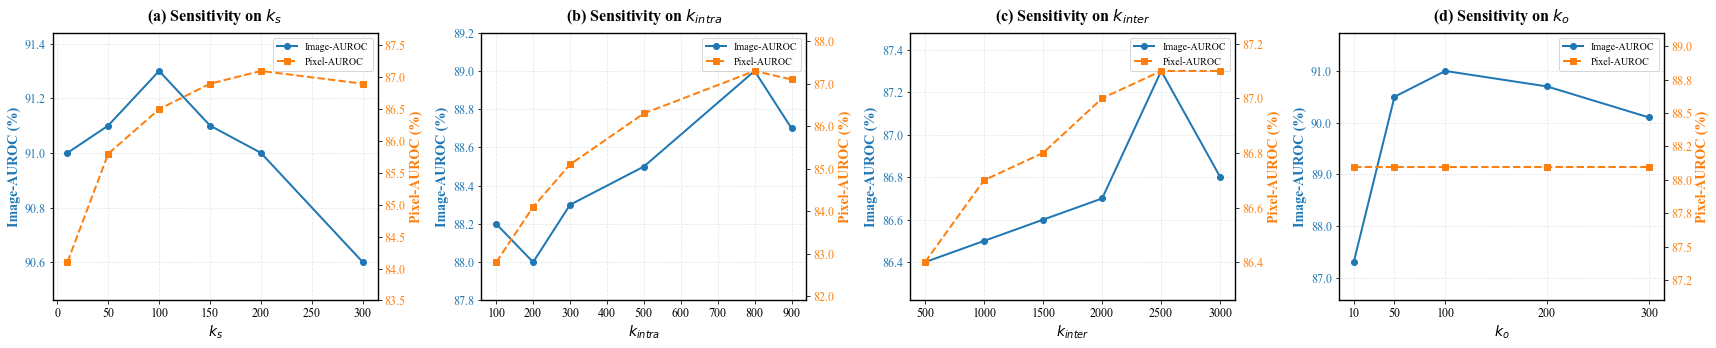

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ================= 1. 数据录入 =================

# (a) Support Set (K_s)
ks_x = [10, 50, 100, 150, 200, 300]
ks_img = [91.0, 91.1, 91.3, 91.1, 91.0, 90.6]
ks_pix = [84.1, 85.8, 86.5, 86.9, 87.1, 86.9]

# (b) Intra-image (K_intra)
kintra_x = [100, 200, 300, 500, 800, 900]
kintra_img = [88.2, 88.0, 88.3, 88.5, 89.0, 88.7]
kintra_pix = [82.8, 84.1, 85.1, 86.3, 87.3, 87.1]

# (c) Inter-image (K_inter)
kinter_x = [500, 1000, 1500, 2000, 2500, 3000]
kinter_img = [86.4, 86.5, 86.6, 86.7, 87.3, 86.8]
kinter_pix = [86.4, 86.7, 86.8, 87.0, 87.1, 87.1]

# (d) Scoring Top-K (k_o)
ko_x = [10, 50, 100, 200, 300]
ko_img = [87.3, 90.5, 91.0, 90.7, 90.1]
ko_pix = [88.1, 88.1, 88.1, 88.1, 88.1]


# ================= 2. 全局样式设置 =================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2

# 颜色定义
color_img = '#1f77b4'  # 蓝色 (Image)
color_pix = '#ff7f0e'  # 橙色 (Pixel)

# 创建画布：改为 1行4列，宽度加大，高度减小
fig, axs = plt.subplots(1, 4, figsize=(24, 5)) 
plt.subplots_adjust(wspace=0.45) # 增加水平间距，防止双Y轴标签重叠

# ================= 3. 绘图核心函数 =================
def plot_subplot(ax_left, x_data, img_data, pix_data, title, xlabel):
    # --- 左轴: Image AUROC (蓝色实线) ---
    ln1 = ax_left.plot(x_data, img_data, color=color_img, marker='o', linestyle='-', 
                       linewidth=2, markersize=6, label='Image-AUROC')
    
    ax_left.set_xlabel(xlabel, fontsize=14, fontweight='bold')
    ax_left.set_ylabel('Image-AUROC (%)', color=color_img, fontsize=14, fontweight='bold')
    ax_left.tick_params(axis='y', labelcolor=color_img, labelsize=12)
    ax_left.tick_params(axis='x', labelsize=12)
    ax_left.grid(True, linestyle='--', alpha=0.3) 

    # 设置左轴范围
    min_img, max_img = min(img_data), max(img_data)
    pad_img = (max_img - min_img) * 0.2 if max_img != min_img else 1.0
    ax_left.set_ylim(min_img - pad_img, max_img + pad_img)
    ax_left.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    # --- 右轴: Pixel AUROC (橙色虚线) ---
    ax_right = ax_left.twinx()
    ln2 = ax_right.plot(x_data, pix_data, color=color_pix, marker='s', linestyle='--', 
                        linewidth=2, markersize=6, label='Pixel-AUROC')
    
    ax_right.set_ylabel('Pixel-AUROC (%)', color=color_pix, fontsize=14, fontweight='bold')
    ax_right.tick_params(axis='y', labelcolor=color_pix, labelsize=12)

    # 设置右轴范围
    min_pix, max_pix = min(pix_data), max(pix_data)
    pad_pix = (max_pix - min_pix) * 0.2 if max_pix != min_pix else 1.0
    ax_right.set_ylim(min_pix - pad_pix, max_pix + pad_pix)
    ax_right.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    # --- 标题与图例 ---
    ax_left.set_title(title, fontsize=16, fontweight='bold', pad=12)
    
    # 合并图例
    lns = ln1 + ln2
    labs = [l.get_label() for l in lns]
    ax_left.legend(lns, labs, loc='best', fontsize=10, frameon=True)

# ================= 4. 执行绘图 (改为一维索引) =================

# (a) Support Set K_s -> axs[0]
plot_subplot(axs[0], ks_x, ks_img, ks_pix, 
             title=r'(a) Sensitivity on $k_s$', 
             xlabel=r'$k_s$')

# (b) Intra-image K_intra -> axs[1]
plot_subplot(axs[1], kintra_x, kintra_img, kintra_pix, 
             title=r'(b) Sensitivity on $k_{intra}$', 
             xlabel=r'$k_{intra}$')

# (c) Inter-image K_inter -> axs[2]
plot_subplot(axs[2], kinter_x, kinter_img, kinter_pix, 
             title=r'(c) Sensitivity on $k_{inter}$', 
             xlabel=r'$k_{inter}$')

# (d) Scoring k_o -> axs[3]
plot_subplot(axs[3], ko_x, ko_img, ko_pix, 
             title=r'(d) Sensitivity on $k_{o}$', 
             xlabel=r'$k_{o}$')
# 手动设置X轴刻度
axs[3].set_xticks(ko_x)

# 保存图片
plt.tight_layout()
plt.savefig('sensitivity_casting_billet_1x4.pdf', bbox_inches='tight')
plt.savefig('sensitivity_casting_billet_1x4.png', dpi=300, bbox_inches='tight')
plt.show()

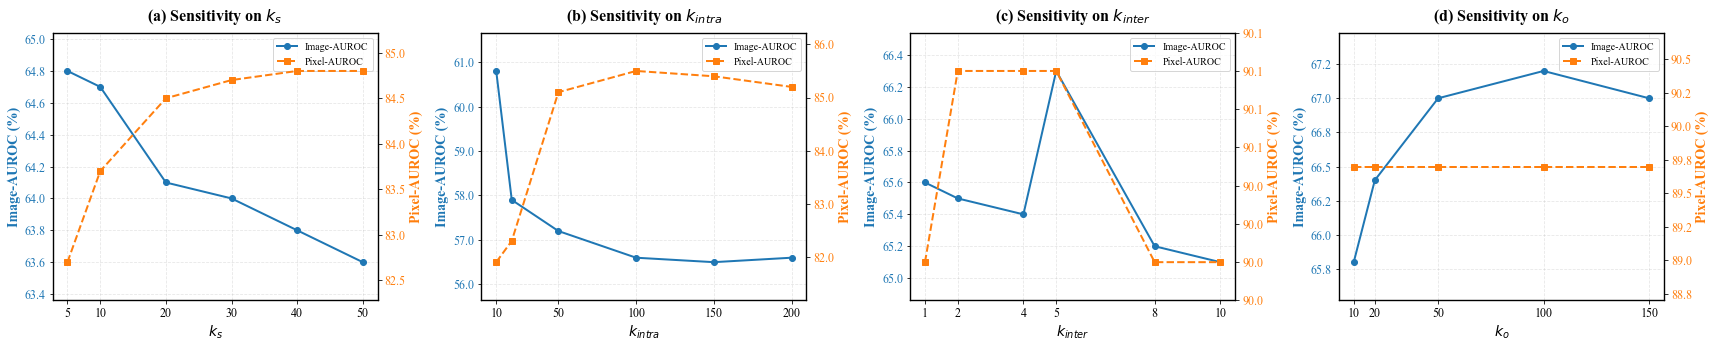

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ================= 1. 数据录入 (Steel Pipe) =================

# (a) Support Set (K_s)
# Data: 5, 10, 20, 30, 40, 50
ks_x = [5, 10, 20, 30, 40, 50]
ks_img = [64.8, 64.7, 64.1, 64.0, 63.8, 63.6]
ks_pix = [82.7, 83.7, 84.5, 84.7, 84.8, 84.8]

# (b) Intra-image (K_intra)
# Data: 10, 20, 50, 100, 150, 200
kintra_x = [10, 20, 50, 100, 150, 200]
kintra_img = [60.8, 57.9, 57.2, 56.6, 56.5, 56.6]
kintra_pix = [81.9, 82.3, 85.1, 85.5, 85.4, 85.2]

# (c) Inter-image (K_inter)
# Data: 1, 2, 4, 5, 8, 10
kinter_x = [1, 2, 4, 5, 8, 10]
kinter_img = [65.6, 65.5, 65.4, 66.3, 65.2, 65.1]
kinter_pix = [90.0, 90.1, 90.1, 90.1, 90.0, 90.0]

# (d) Scoring Top-K (k_o)
# Data: 10, 20, 50, 100, 150
ko_x = [10, 20, 50, 100, 150]
ko_img = [65.8, 66.4, 67.0, 67.2, 67.0]
ko_pix = [89.7, 89.7, 89.7, 89.7, 89.7]


# ================= 2. 全局样式设置 =================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2

# 颜色定义
color_img = '#1f77b4'  # 蓝色 (Image)
color_pix = '#ff7f0e'  # 橙色 (Pixel)

# 创建画布：1行4列
fig, axs = plt.subplots(1, 4, figsize=(24, 5)) 
plt.subplots_adjust(wspace=0.45) # 增加水平间距

# ================= 3. 绘图核心函数 =================
def plot_subplot(ax_left, x_data, img_data, pix_data, title, xlabel):
    # --- 左轴: Image AUROC (蓝色实线) ---
    ln1 = ax_left.plot(x_data, img_data, color=color_img, marker='o', linestyle='-', 
                       linewidth=2, markersize=6, label='Image-AUROC')
    
    ax_left.set_xlabel(xlabel, fontsize=14, fontweight='bold')
    ax_left.set_ylabel('Image-AUROC (%)', color=color_img, fontsize=14, fontweight='bold')
    ax_left.tick_params(axis='y', labelcolor=color_img, labelsize=12)
    ax_left.tick_params(axis='x', labelsize=12)
    ax_left.grid(True, linestyle='--', alpha=0.3) 

    # 设置左轴范围 (自动计算)
    min_img, max_img = min(img_data), max(img_data)
    pad_img = (max_img - min_img) * 0.2 if max_img != min_img else 1.0
    ax_left.set_ylim(min_img - pad_img, max_img + pad_img)
    ax_left.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    # --- 右轴: Pixel AUROC (橙色虚线) ---
    ax_right = ax_left.twinx()
    ln2 = ax_right.plot(x_data, pix_data, color=color_pix, marker='s', linestyle='--', 
                        linewidth=2, markersize=6, label='Pixel-AUROC')
    
    ax_right.set_ylabel('Pixel-AUROC (%)', color=color_pix, fontsize=14, fontweight='bold')
    ax_right.tick_params(axis='y', labelcolor=color_pix, labelsize=12)

    # 设置右轴范围
    min_pix, max_pix = min(pix_data), max(pix_data)
    pad_pix = (max_pix - min_pix) * 0.2 if max_pix != min_pix else 1.0
    ax_right.set_ylim(min_pix - pad_pix, max_pix + pad_pix)
    ax_right.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    # --- 标题与图例 ---
    ax_left.set_title(title, fontsize=16, fontweight='bold', pad=12)
    
    # 合并图例
    lns = ln1 + ln2
    labs = [l.get_label() for l in lns]
    ax_left.legend(lns, labs, loc='best', fontsize=10, frameon=True)

# ================= 4. 执行绘图 =================

# (a) Support Set K_s -> axs[0]
plot_subplot(axs[0], ks_x, ks_img, ks_pix, 
             title=r'(a) Sensitivity on $k_s$', 
             xlabel=r'$k_s$')
axs[0].set_xticks(ks_x) # 显式设置刻度

# (b) Intra-image K_intra -> axs[1]
plot_subplot(axs[1], kintra_x, kintra_img, kintra_pix, 
             title=r'(b) Sensitivity on $k_{intra}$', 
             xlabel=r'$k_{intra}$')
axs[1].set_xticks([10, 50, 100, 150, 200]) # 稍微稀疏一点以免拥挤

# (c) Inter-image K_inter -> axs[2]
plot_subplot(axs[2], kinter_x, kinter_img, kinter_pix, 
             title=r'(c) Sensitivity on $k_{inter}$', 
             xlabel=r'$k_{inter}$')
axs[2].set_xticks(kinter_x) # 显式设置刻度

# (d) Scoring k_o -> axs[3]
plot_subplot(axs[3], ko_x, ko_img, ko_pix, 
             title=r'(d) Sensitivity on $k_{o}$', 
             xlabel=r'$k_{o}$')
axs[3].set_xticks(ko_x) # 显式设置刻度

# 保存图片
plt.tight_layout()
plt.savefig('sensitivity_steel_pipe_1x4.pdf', bbox_inches='tight')
plt.savefig('sensitivity_steel_pipe_1x4.png', dpi=300, bbox_inches='tight')
plt.show()

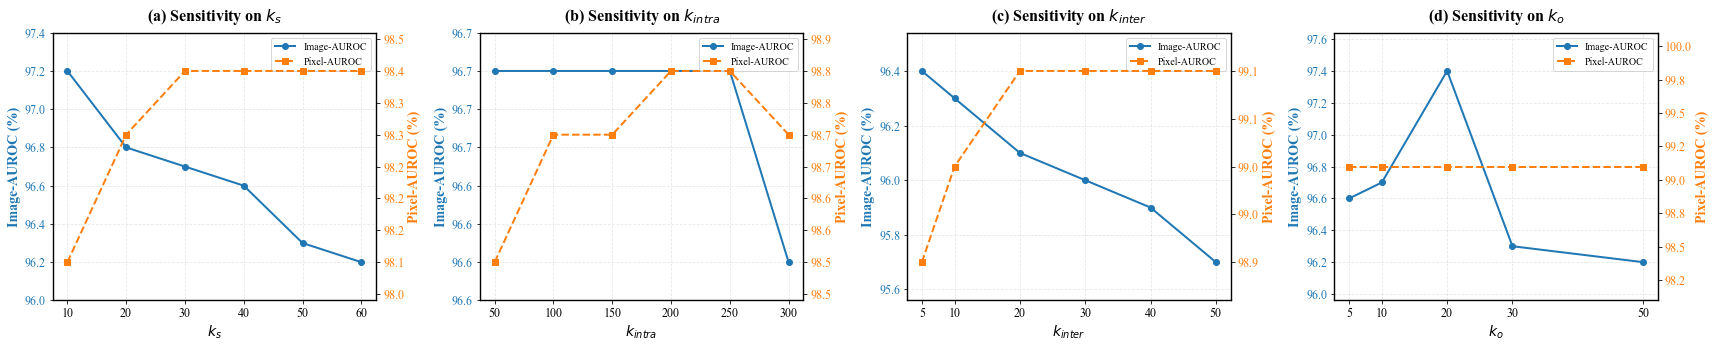

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ================= 1. 数据录入 (KSDD) =================

# (a) Support Set (K_s)
# Data: 10, 20, 30, 40, 50, 60
ks_x = [10, 20, 30, 40, 50, 60]
ks_img = [97.2, 96.8, 96.7, 96.6, 96.3, 96.2]
ks_pix = [98.1, 98.3, 98.4, 98.4, 98.4, 98.4]

# (b) Intra-image (K_intra)
# Data: 50, 100, 150, 200, 250, 300
kintra_x = [50, 100, 150, 200, 250, 300]
kintra_img = [96.7, 96.7, 96.7, 96.7, 96.7, 96.6]
kintra_pix = [98.5, 98.7, 98.7, 98.8, 98.8, 98.7]

# (c) Inter-image (K_inter)
# Data: 5, 10, 20, 30, 40, 50
kinter_x = [5, 10, 20, 30, 40, 50]
kinter_img = [96.4, 96.3, 96.1, 96.0, 95.9, 95.7]
kinter_pix = [98.9, 99.0, 99.1, 99.1, 99.1, 99.1]

# (d) Scoring Top-K (k_o)
# Data: 5, 10, 20, 30, 50
ko_x = [5, 10, 20, 30, 50]
ko_img = [96.6, 96.7, 97.4, 96.3, 96.2]
ko_pix = [99.1, 99.1, 99.1, 99.1, 99.1]


# ================= 2. 全局样式设置 =================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2

# 颜色定义
color_img = '#1f77b4'  # 蓝色 (Image)
color_pix = '#ff7f0e'  # 橙色 (Pixel)

# 创建画布：1行4列
fig, axs = plt.subplots(1, 4, figsize=(24, 5)) 
plt.subplots_adjust(wspace=0.45) # 增加水平间距

# ================= 3. 绘图核心函数 =================
def plot_subplot(ax_left, x_data, img_data, pix_data, title, xlabel):
    # --- 左轴: Image AUROC (蓝色实线) ---
    ln1 = ax_left.plot(x_data, img_data, color=color_img, marker='o', linestyle='-', 
                       linewidth=2, markersize=6, label='Image-AUROC')
    
    ax_left.set_xlabel(xlabel, fontsize=14, fontweight='bold')
    ax_left.set_ylabel('Image-AUROC (%)', color=color_img, fontsize=14, fontweight='bold')
    ax_left.tick_params(axis='y', labelcolor=color_img, labelsize=12)
    ax_left.tick_params(axis='x', labelsize=12)
    ax_left.grid(True, linestyle='--', alpha=0.3) 

    # 设置左轴范围 (自动计算)
    min_img, max_img = min(img_data), max(img_data)
    pad_img = (max_img - min_img) * 0.2 if max_img != min_img else 1.0
    ax_left.set_ylim(min_img - pad_img, max_img + pad_img)
    ax_left.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    # --- 右轴: Pixel AUROC (橙色虚线) ---
    ax_right = ax_left.twinx()
    ln2 = ax_right.plot(x_data, pix_data, color=color_pix, marker='s', linestyle='--', 
                        linewidth=2, markersize=6, label='Pixel-AUROC')
    
    ax_right.set_ylabel('Pixel-AUROC (%)', color=color_pix, fontsize=14, fontweight='bold')
    ax_right.tick_params(axis='y', labelcolor=color_pix, labelsize=12)

    # 设置右轴范围
    min_pix, max_pix = min(pix_data), max(pix_data)
    pad_pix = (max_pix - min_pix) * 0.2 if max_pix != min_pix else 1.0
    ax_right.set_ylim(min_pix - pad_pix, max_pix + pad_pix)
    ax_right.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    # --- 标题与图例 ---
    ax_left.set_title(title, fontsize=16, fontweight='bold', pad=12)
    
    # 合并图例
    lns = ln1 + ln2
    labs = [l.get_label() for l in lns]
    ax_left.legend(lns, labs, loc='best', fontsize=10, frameon=True)

# ================= 4. 执行绘图 =================

# (a) Support Set K_s -> axs[0]
plot_subplot(axs[0], ks_x, ks_img, ks_pix, 
             title=r'(a) Sensitivity on $k_s$', 
             xlabel=r'$k_s$')
axs[0].set_xticks(ks_x)

# (b) Intra-image K_intra -> axs[1]
plot_subplot(axs[1], kintra_x, kintra_img, kintra_pix, 
             title=r'(b) Sensitivity on $k_{intra}$', 
             xlabel=r'$k_{intra}$')
axs[1].set_xticks(kintra_x)

# (c) Inter-image K_inter -> axs[2]
plot_subplot(axs[2], kinter_x, kinter_img, kinter_pix, 
             title=r'(c) Sensitivity on $k_{inter}$', 
             xlabel=r'$k_{inter}$')
axs[2].set_xticks(kinter_x)

# (d) Scoring k_o -> axs[3]
plot_subplot(axs[3], ko_x, ko_img, ko_pix, 
             title=r'(d) Sensitivity on $k_{o}$', 
             xlabel=r'$k_{o}$')
axs[3].set_xticks(ko_x)

# 保存图片
plt.tight_layout()
plt.savefig('sensitivity_ksdd_1x4.pdf', bbox_inches='tight')
plt.savefig('sensitivity_ksdd_1x4.png', dpi=300, bbox_inches='tight')
plt.show()

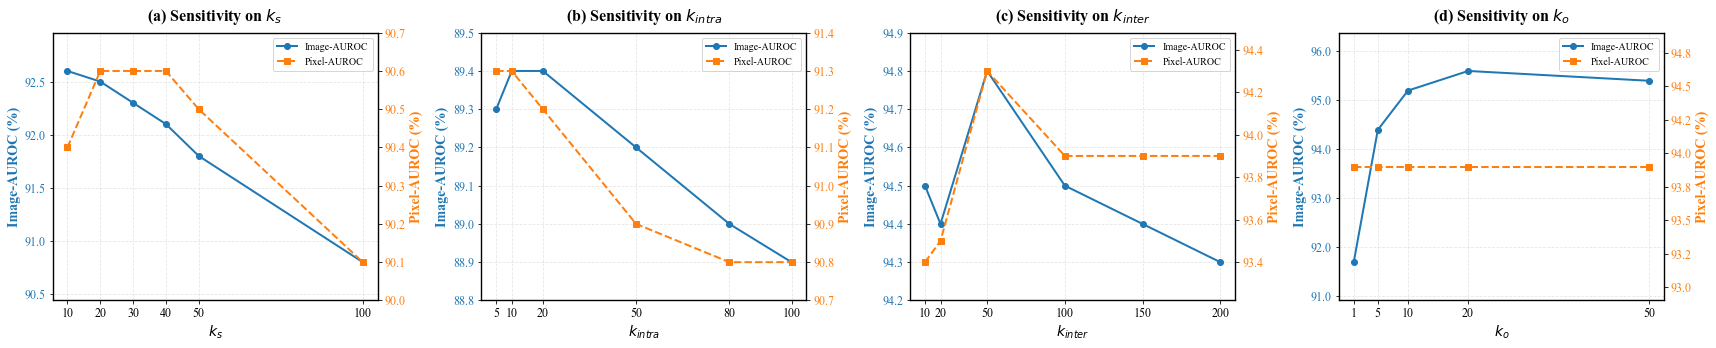

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ================= 1. 数据录入 (MVTec) =================

# (a) Support Set (K_s)
# Data: 10, 20, 30, 40, 50, 100
ks_x = [10, 20, 30, 40, 50, 100]
ks_img = [92.6, 92.5, 92.3, 92.1, 91.8, 90.8]
ks_pix = [90.4, 90.6, 90.6, 90.6, 90.5, 90.1]

# (b) Intra-image (K_intra)
# Data: 5, 10, 20, 50, 80, 100
kintra_x = [5, 10, 20, 50, 80, 100]
kintra_img = [89.3, 89.4, 89.4, 89.2, 89.0, 88.9]
kintra_pix = [91.3, 91.3, 91.2, 90.9, 90.8, 90.8]

# (c) Inter-image (K_inter)
# Data: 10, 20, 50, 100, 150, 200
kinter_x = [10, 20, 50, 100, 150, 200]
kinter_img = [94.5, 94.4, 94.8, 94.5, 94.4, 94.3]
kinter_pix = [93.4, 93.5, 94.3, 93.9, 93.9, 93.9]

# (d) Scoring Top-K (k_o)
# Data: 1, 5, 10, 20, 50
ko_x = [1, 5, 10, 20, 50]
ko_img = [91.7, 94.4, 95.2, 95.6, 95.4]
ko_pix = [93.9, 93.9, 93.9, 93.9, 93.9]


# ================= 2. 全局样式设置 =================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2

# 颜色定义
color_img = '#1f77b4'  # 蓝色 (Image)
color_pix = '#ff7f0e'  # 橙色 (Pixel)

# 创建画布：1行4列
fig, axs = plt.subplots(1, 4, figsize=(24, 5)) 
plt.subplots_adjust(wspace=0.45) # 增加水平间距

# ================= 3. 绘图核心函数 =================
def plot_subplot(ax_left, x_data, img_data, pix_data, title, xlabel):
    # --- 左轴: Image AUROC (蓝色实线) ---
    ln1 = ax_left.plot(x_data, img_data, color=color_img, marker='o', linestyle='-', 
                       linewidth=2, markersize=6, label='Image-AUROC')
    
    ax_left.set_xlabel(xlabel, fontsize=14, fontweight='bold')
    ax_left.set_ylabel('Image-AUROC (%)', color=color_img, fontsize=14, fontweight='bold')
    ax_left.tick_params(axis='y', labelcolor=color_img, labelsize=12)
    ax_left.tick_params(axis='x', labelsize=12)
    ax_left.grid(True, linestyle='--', alpha=0.3) 

    # 设置左轴范围 (自动计算)
    min_img, max_img = min(img_data), max(img_data)
    pad_img = (max_img - min_img) * 0.2 if max_img != min_img else 1.0
    ax_left.set_ylim(min_img - pad_img, max_img + pad_img)
    ax_left.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    # --- 右轴: Pixel AUROC (橙色虚线) ---
    ax_right = ax_left.twinx()
    ln2 = ax_right.plot(x_data, pix_data, color=color_pix, marker='s', linestyle='--', 
                        linewidth=2, markersize=6, label='Pixel-AUROC')
    
    ax_right.set_ylabel('Pixel-AUROC (%)', color=color_pix, fontsize=14, fontweight='bold')
    ax_right.tick_params(axis='y', labelcolor=color_pix, labelsize=12)

    # 设置右轴范围
    min_pix, max_pix = min(pix_data), max(pix_data)
    pad_pix = (max_pix - min_pix) * 0.2 if max_pix != min_pix else 1.0
    ax_right.set_ylim(min_pix - pad_pix, max_pix + pad_pix)
    ax_right.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    # --- 标题与图例 ---
    ax_left.set_title(title, fontsize=16, fontweight='bold', pad=12)
    
    # 合并图例
    lns = ln1 + ln2
    labs = [l.get_label() for l in lns]
    ax_left.legend(lns, labs, loc='best', fontsize=10, frameon=True)

# ================= 4. 执行绘图 =================

# (a) Support Set K_s -> axs[0]
plot_subplot(axs[0], ks_x, ks_img, ks_pix, 
             title=r'(a) Sensitivity on $k_s$', 
             xlabel=r'$k_s$')
axs[0].set_xticks(ks_x) # 显式设置刻度

# (b) Intra-image K_intra -> axs[1]
plot_subplot(axs[1], kintra_x, kintra_img, kintra_pix, 
             title=r'(b) Sensitivity on $k_{intra}$', 
             xlabel=r'$k_{intra}$')
axs[1].set_xticks(kintra_x)

# (c) Inter-image K_inter -> axs[2]
plot_subplot(axs[2], kinter_x, kinter_img, kinter_pix, 
             title=r'(c) Sensitivity on $k_{inter}$', 
             xlabel=r'$k_{inter}$')
axs[2].set_xticks(kinter_x)

# (d) Scoring k_o -> axs[3]
plot_subplot(axs[3], ko_x, ko_img, ko_pix, 
             title=r'(d) Sensitivity on $k_{o}$', 
             xlabel=r'$k_{o}$')
axs[3].set_xticks(ko_x)

# 保存图片
plt.tight_layout()
plt.savefig('sensitivity_mvtec_1x4.pdf', bbox_inches='tight')
plt.savefig('sensitivity_mvtec_1x4.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ================= 1. 全局样式设置 =================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2

# 颜色定义
COLOR_IMG = '#1f77b4'  # 蓝色 (Image-AUROC)
COLOR_PIX = '#ff7f0e'  # 橙色 (Pixel-AUROC)

# ================= 2. 绘图核心函数 =================
def plot_sensitivity(dataset_name, data_dict):
    """
    dataset_name: 字符串, 如 "VisA"
    data_dict: 字典, 包含 ks, kintra, kinter, ko 四组数据
    """
    
    # 创建画布：1行4列
    fig, axs = plt.subplots(1, 4, figsize=(24, 5))
    plt.subplots_adjust(wspace=0.45) # 调整子图间距

    # 定义4个子图的配置
    configs = [
        ('ks',      r'(a) Sensitivity on $K_s$',       r'$K_s$'),
        ('kintra',  r'(b) Sensitivity on $K_{intra}$', r'$K_{intra}$'),
        ('kinter',  r'(c) Sensitivity on $K_{inter}$', r'$K_{inter}$'),
        ('ko',      r'(d) Sensitivity on $K_{o}$',     r'$K_{score}$')
    ]

    for i, (key, title, xlabel) in enumerate(configs):
        ax_left = axs[i]
        
        # 获取数据
        x_data = data_dict[key]['x']
        img_data = data_dict[key]['img']
        pix_data = data_dict[key]['pix']

        # --- 左轴: Image AUROC ---
        ln1 = ax_left.plot(x_data, img_data, color=COLOR_IMG, marker='o', linestyle='-', 
                           linewidth=2, markersize=6, label='Image-AUROC')
        
        ax_left.set_xlabel(xlabel, fontsize=14, fontweight='bold')
        ax_left.set_ylabel('Image-AUROC (%)', color=COLOR_IMG, fontsize=14, fontweight='bold')
        ax_left.tick_params(axis='y', labelcolor=COLOR_IMG, labelsize=12)
        ax_left.tick_params(axis='x', labelsize=12)
        ax_left.set_xticks(x_data) # 强制显示所有X轴刻度
        ax_left.grid(True, linestyle='--', alpha=0.3)

        # 自动调整左轴范围
        min_img, max_img = min(img_data), max(img_data)
        pad_img = (max_img - min_img) * 0.2 if max_img != min_img else 1.0
        ax_left.set_ylim(min_img - pad_img, max_img + pad_img)
        ax_left.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

        # --- 右轴: Pixel AUROC ---
        ax_right = ax_left.twinx()
        ln2 = ax_right.plot(x_data, pix_data, color=COLOR_PIX, marker='s', linestyle='--', 
                            linewidth=2, markersize=6, label='Pixel-AUROC')
        
        ax_right.set_ylabel('Pixel-AUROC (%)', color=COLOR_PIX, fontsize=14, fontweight='bold')
        ax_right.tick_params(axis='y', labelcolor=COLOR_PIX, labelsize=12)

        # 自动调整右轴范围
        min_pix, max_pix = min(pix_data), max(pix_data)
        pad_pix = (max_pix - min_pix) * 0.2 if max_pix != min_pix else 1.0
        ax_right.set_ylim(min_pix - pad_pix, max_pix + pad_pix)
        ax_right.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

        # --- 标题与图例 ---
        ax_left.set_title(title, fontsize=16, fontweight='bold', pad=12)
        
        lns = ln1 + ln2
        labs = [l.get_label() for l in lns]
        ax_left.legend(lns, labs, loc='best', fontsize=10, frameon=True)

    # 保存文件
    filename = f"sensitivity_{dataset_name.lower().replace(' ', '_')}_1x4"
    plt.tight_layout()
    plt.savefig(f"{filename}.pdf", bbox_inches='tight')
    plt.savefig(f"{filename}.png", dpi=300, bbox_inches='tight')
    print(f"Generated: {filename}.pdf")
    plt.close() # 关闭画布释放内存

# ================= 3. 数据准备 =================

# 1. Casting Billet
data_casting = {
    'ks':     {'x': [10, 50, 100, 150, 200, 300], 'img': [91.0, 91.1, 91.3, 91.1, 91.0, 90.6], 'pix': [84.1, 85.8, 86.5, 86.9, 87.1, 86.9]},
    'kintra': {'x': [100, 200, 300, 500, 800, 900], 'img': [87.2, 87.0, 87.3, 87.5, 89.0, 87.7], 'pix': [82.8, 84.1, 85.1, 86.3, 87.3, 87.1]},
    'kinter': {'x': [500, 1000, 1500, 2000, 2500, 3000], 'img': [86.4, 86.5, 86.6, 86.7, 87.3, 86.8], 'pix': [86.4, 86.7, 86.8, 87.0, 87.1, 87.1]},
    'ko':     {'x': [10, 50, 100, 200, 300], 'img': [87.3, 90.5, 91.0, 90.7, 90.1], 'pix': [88.1, 88.1, 88.1, 88.1, 88.1]}
}

# 2. Steel Pipe
data_steel = {
    'ks':     {'x': [5, 10, 20, 30, 40, 50], 'img': [64.8, 64.7, 64.1, 64.0, 63.8, 63.6], 'pix': [82.7, 83.7, 84.5, 84.7, 84.8, 84.8]},
    'kintra': {'x': [10, 20, 50, 100, 150, 200], 'img': [60.8, 57.9, 57.2, 56.6, 56.5, 56.6], 'pix': [81.9, 82.3, 85.1, 85.5, 85.4, 85.2]},
    'kinter': {'x': [1, 2, 4, 5, 8, 10], 'img': [65.6, 65.5, 65.4, 66.3, 65.2, 65.1], 'pix': [90.0, 90.1, 90.1, 90.1, 90.0, 90.0]},
    'ko':     {'x': [10, 20, 50, 100, 150], 'img': [65.8, 66.4, 67.0, 67.2, 67.0], 'pix': [89.7, 89.7, 89.7, 89.7, 89.7]}
}

# 3. KSDD
data_ksdd = {
    'ks':     {'x': [10, 20, 30, 40, 50, 60], 'img': [97.2, 96.8, 96.7, 96.6, 96.3, 96.2], 'pix': [98.1, 98.3, 98.4, 98.4, 98.4, 98.4]},
    'kintra': {'x': [50, 100, 150, 200, 250, 300], 'img': [96.7, 96.7, 96.7, 96.7, 96.7, 96.6], 'pix': [98.5, 98.7, 98.7, 98.8, 98.8, 98.7]},
    'kinter': {'x': [5, 10, 20, 30, 40, 50], 'img': [96.4, 96.3, 96.1, 96.0, 95.9, 95.7], 'pix': [98.9, 99.0, 99.1, 99.1, 99.1, 99.1]},
    'ko':     {'x': [5, 10, 20, 30, 50], 'img': [96.6, 96.7, 97.4, 96.3, 96.2], 'pix': [99.1, 99.1, 99.1, 99.1, 99.1]}
}

# 4. MVTec
data_mvtec = {
    'ks':     {'x': [10, 20, 30, 40, 50, 100], 'img': [92.6, 92.5, 92.3, 92.1, 91.8, 90.8], 'pix': [90.4, 90.6, 90.6, 90.6, 90.5, 90.1]},
    'kintra': {'x': [5, 10, 20, 50, 80, 100], 'img': [89.3, 89.4, 89.4, 89.2, 89.0, 88.9], 'pix': [91.3, 91.3, 91.2, 90.9, 90.8, 90.8]},
    'kinter': {'x': [10, 20, 50, 100, 150, 200], 'img': [94.5, 94.4, 94.8, 94.5, 94.4, 94.3], 'pix': [93.4, 93.5, 94.3, 93.9, 93.9, 93.9]},
    'ko':     {'x': [1, 5, 10, 20, 50], 'img': [91.7, 94.4, 95.2, 95.6, 95.4], 'pix': [93.9, 93.9, 93.9, 93.9, 93.9]}
}

# 5. VisA (Added)
data_visa = {
    'ks':     {'x': [10, 20, 50, 100, 150, 200], 'img': [84.5, 84.4, 84.0, 83.5, 83.4, 83.0], 'pix': [94.2, 94.2, 94.1, 93.9, 93.6, 93.4]},
    'kintra': {'x': [10, 20, 50, 100, 150, 200], 'img': [85.0, 84.8, 85.1, 84.8, 84.6, 84.7], 'pix': [94.5, 94.4, 94.4, 94.4, 94.4, 94.3]},
    'kinter': {'x': [10, 20, 30, 40, 50, 100], 'img': [88.0, 88.1, 88.1, 87.5, 87.3, 87.2], 'pix': [97.4, 98.0, 97.5, 97.9, 97.5, 97.4]},
    'ko':     {'x': [5, 10, 20, 30, 50], 'img': [89.5, 89.8, 89.4, 89.0, 88.3], 'pix': [97.6, 97.6, 97.6, 97.6, 97.6]}
}

# ================= 4. 批量执行 =================
plot_sensitivity("Casting Billet", data_casting)
plot_sensitivity("Steel Pipe", data_steel)
plot_sensitivity("KSDD", data_ksdd)
plot_sensitivity("MVTec", data_mvtec)
plot_sensitivity("VisA", data_visa)

print("\nAll 5 figures have been generated successfully!")

Generated: sensitivity_casting_billet_1x4.pdf
Generated: sensitivity_steel_pipe_1x4.pdf
Generated: sensitivity_ksdd_1x4.pdf
Generated: sensitivity_mvtec_1x4.pdf
Generated: sensitivity_visa_1x4.pdf

All 5 figures have been generated successfully!


In [4]:
import json
from pathlib import Path

# ====== 1) 读取 JSON ======
json_path = "/Users/chuniliu/Desktop/local_code/defect_lvlms/datasets_des_info_gpt4o_v2.json"   # 改成你的文件路径
with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)
print('data ', data)
# ====== 2) 定义判断函数：是否属于 MVTec / VisA ======
def is_mvtec_or_visa(item):
    """
    item: 一条样本（通常是 dict）
    兼容常见字段：
    - item["dataset"]
    - item["samples"] / item["sample"] / item["path"] / item["image"] 等路径字段
    """
    if not isinstance(item, dict):
        return False

    # 先看 dataset 字段（如果有）
    dataset_name = str(item.get("dataset", "")).lower()
    print('dataset_name ', dataset_name)
    #if "mvtec" in dataset_name or "visa" in dataset_name:
    if "casting_billet" in dataset_name or "steel_pipe" in dataset_name:
        return True

    # 再看常见路径字段（如果 dataset 字段没有）
    candidate_fields = ["samples", "sample", "path", "image", "img_path", "file_path"]
    for key in candidate_fields:
        v = item.get(key, None)

        # 字符串路径
        if isinstance(v, str):
            s = v.lower()
            #if "mvtec" in s or "visa" in s:
            if "casting_billet" in s or "steel_pipe" in s:
                return True

        # 列表路径（有些格式 samples 是 list）
        if isinstance(v, list):
            for x in v:
                if isinstance(x, str):
                    s = x.lower()
                    #if "mvtec" in s or "visa" in s:
                    if "casting_billet" in s or "steel_pipe" in s:
                        return True

    return False

# ====== 3) 按 JSON 顶层结构筛选 ======
# 情况 A：顶层是 list
if isinstance(data, list):
    filtered = [item for item in data if is_mvtec_or_visa(item)]

# 情况 B：顶层是 dict（例如 {"data": [...]}）
elif isinstance(data, dict):
    # 优先尝试常见的列表字段
    list_key = None
    for k in ["data", "items", "annotations", "samples"]:
        if isinstance(data.get(k), list):
            list_key = k
            break

    if list_key is not None:
        filtered_list = [item for item in data[list_key] if is_mvtec_or_visa(item)]
        filtered = dict(data)              # 保留原结构
        filtered[list_key] = filtered_list
    else:
        # 如果顶层 dict 本身就是单条记录
        filtered = data if is_mvtec_or_visa(data) else {}

else:
    raise TypeError("Unsupported JSON top-level type. Expected list or dict.")

filtered['casting_billet'] = data['casting_billet']
filtered['steel_pipe'] = data['steel_pipe']

# ====== 4) 保存结果 ======
out_path = "/Users/chuniliu/Desktop/local_code/defect_lvlms/datasets_des_info_own_part.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(filtered, f, ensure_ascii=False, indent=2)

# ====== 5) 打印统计 ======
if isinstance(filtered, list):
    print(f"Filtered items: {len(filtered)}")
elif isinstance(filtered, dict):
    # 尝试打印列表字段长度
    for k in ["data", "items", "annotations", "samples"]:
        if isinstance(filtered.get(k), list):
            print(f"Filtered items in '{k}': {len(filtered[k])}")
            break
    else:
        print("Filtered result saved (dict structure).")

print(f"Saved to: {out_path}")

data  {'AITEX': {'des': {'good': ['{} which should be without any damage', '{} which should be without any flaw', '{} which should be without any defect', '{} which should be without any irregularities', '{} which should be without any faults', '{} which should be without any scratches', '{} which should be without any hole', '{} which should be without any stains', '{} which should be without any slubs', '{} which should be without any color inconsistencies'], 'defect': ['{} with broken end defect, it appears as  equidistant horizontal or vertical lines along the fabric width, irregular gaps or missing warp threads, disturbances in the pattern continuity', '{} with broken yarn defect, it appears as  visible breaks in the yarn, causing a discontinuity in the fabric pattern, potentially causing a loose or unraveling edge', '{} with broken pick defect, it appears as  as a broken filling yarn in the fabric weaving. it appears as a sharp discontinuity in the weave pattern over the pick len